## 1. Verifikasi Dependensi


In [ ]:
import importlib.util

_REQUIRED = [
    "torch", "torchaudio", "soundfile", "onedrivedownloader",
    "pandas", "sklearn", "matplotlib", "tabulate", "scipy", "numpy",
]
_missing = [m for m in _REQUIRED if importlib.util.find_spec(m) is None]
if _missing:
    raise RuntimeError(
        "Dependensi belum terpasang: " + ", ".join(_missing) + ". "
        "Jalankan `pip install -r requirements.txt` (root repo) sebelum "
        "menjalankan notebook ini."
    )
print("Semua dependensi terpasang (lihat requirements.txt di root repo).")


### 1b. Verifikasi GPU


In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("GPU tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("PERINGATAN: tidak ada GPU terdeteksi -- fine-tuning transformer di "
          "CPU sangat lambat. Kalau memakai Colab: Runtime > Change runtime type > GPU.")


PyTorch: 2.6.0+cu126
CUDA build: 12.6
GPU tersedia: False
PERINGATAN: tidak ada GPU terdeteksi -- fine-tuning transformer di CPU sangat lambat. Kalau memakai Colab: Runtime > Change runtime type > GPU.


c:\Users\Nico\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Source BEATs (vendored lokal)


In [6]:
import sys
from pathlib import Path

BEATS_DIR = Path("../third_party/unilm/beats")
if not BEATS_DIR.exists():
    raise RuntimeError(
        f"{BEATS_DIR} tidak ditemukan. Notebook ini tidak lagi meng-clone BEATs "
        "secara otomatis -- vendor manual dulu (lihat README.md) sebelum lanjut."
    )

sys.path.insert(0, str(BEATS_DIR.resolve()))
print("BEATs source siap dari:", BEATS_DIR.resolve())


BEATs source siap dari: C:\Users\Nico\OneDrive - Bina Nusantara\Documents\BINUS\lomba\compfest\code\audiax_model\third_party\unilm\beats


## 3. Checkpoint BEATs Pretrained (lokal, `models/`)


In [ ]:
import os

BASE_CHECKPOINT = "../models/BEATs_iter3_plus_AS20K.pt"
MIN_VALID_SIZE_BYTES = 300_000_000


def _looks_valid(path: str) -> bool:
    return os.path.exists(path) and os.path.getsize(path) > MIN_VALID_SIZE_BYTES


if not _looks_valid(BASE_CHECKPOINT):
    raise RuntimeError(
        f"Checkpoint tidak ditemukan atau tidak valid: {BASE_CHECKPOINT}. "
        "Notebook ini tidak lagi mengunduh checkpoint secara otomatis -- taruh "
        "file .pt di folder models/ sebelum menjalankan sel ini."
    )

print(f"Checkpoint pretrained siap: {BASE_CHECKPOINT} "
      f"({os.path.getsize(BASE_CHECKPOINT)/1e6:.0f} MB)")


## 4. Dataset — Pilih Mode


In [ ]:
DATASET_MODE = "custom"

assert DATASET_MODE in ("mimii", "custom"), f"DATASET_MODE tidak dikenal: {DATASET_MODE}"
print(f"DATASET_MODE = {DATASET_MODE}")


### 4a. Mode `"mimii"` — Unduh Dataset Publik (`-6_dB_fan`, ~10.9 GB)


In [13]:
import hashlib

if DATASET_MODE == "mimii":
    MIMII_ROOT = "mimii_data"
    MIMII_ZIP_URL = "https://zenodo.org/records/3384388/files/-6_dB_fan.zip?download=1"
    MIMII_ZIP_NAME = "-6_dB_fan.zip"
    MIMII_ZIP_MD5 = "f02ae808a58d84b6815b7ec38ff30879"
    MIMII_ZIP_MIN_SIZE = 10_000_000_000

    def _md5sum(path: str, chunk_size: int = 8 * 1024 * 1024) -> str:
        h = hashlib.md5()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(chunk_size), b""):
                h.update(chunk)
        return h.hexdigest()

    os.makedirs(MIMII_ROOT, exist_ok=True)
    extracted_marker = os.path.join(MIMII_ROOT, "-6_dB_fan")

    if os.path.isdir(extracted_marker) and len(os.listdir(extracted_marker)) > 0:
        print(f"Dataset sudah terekstrak di {extracted_marker} -- lewati unduhan.")
    else:
        if not os.path.exists(MIMII_ZIP_NAME) or os.path.getsize(MIMII_ZIP_NAME) < MIMII_ZIP_MIN_SIZE:
            print("Mengunduh -6_dB_fan.zip (~10.9 GB) -- bisa lama...")
            os.system(f"wget -c -q --show-progress '{MIMII_ZIP_URL}' -O {MIMII_ZIP_NAME}")
        assert os.path.exists(MIMII_ZIP_NAME) and os.path.getsize(MIMII_ZIP_NAME) >= MIMII_ZIP_MIN_SIZE, (
            f"Unduhan tidak lengkap: {os.path.getsize(MIMII_ZIP_NAME)/1e9:.2f} GB, seharusnya ~10.9 GB."
        )
        print("Memverifikasi checksum MD5...")
        actual_md5 = _md5sum(MIMII_ZIP_NAME)
        assert actual_md5 == MIMII_ZIP_MD5, f"Checksum tidak cocok! {actual_md5} != {MIMII_ZIP_MD5}"
        print("Checksum cocok. Mengekstrak...")
        os.makedirs(extracted_marker, exist_ok=True)
        os.system(f"unzip -q -o {MIMII_ZIP_NAME} -d {extracted_marker}")

    assert os.path.isdir(extracted_marker), f"{extracted_marker} tidak ditemukan setelah ekstraksi."
    DATASET_ROOT = MIMII_ROOT
    print("Dataset MIMII siap di:", extracted_marker)
else:
    print("DATASET_MODE != 'mimii' -- sel unduhan dilewati.")

DATASET_MODE != 'mimii' -- sel unduhan dilewati.


### 4b. Mode `"custom"` — Dataset Lapangan/Kustom Anda


In [ ]:
if DATASET_MODE == "custom":
    from pathlib import Path
    CUSTOM_DATASET_ROOT = "../Dataset/fan"

    assert os.path.isdir(CUSTOM_DATASET_ROOT), f"Folder dataset tidak ditemukan: {CUSTOM_DATASET_ROOT}"
    custom_ids = sorted(
        p.name for p in Path(CUSTOM_DATASET_ROOT).iterdir()
        if p.is_dir() and p.name.startswith("id_")
    )
    assert len(custom_ids) > 0, (
        f"Tidak ada subfolder id_XX/ di bawah {CUSTOM_DATASET_ROOT}. Struktur yang "
        "diharapkan: <CUSTOM_DATASET_ROOT>/id_XX/{normal,abnormal}/*.wav."
    )

    n_normal, n_abnormal = 0, 0
    for mid in custom_ids:
        assert os.path.isdir(os.path.join(CUSTOM_DATASET_ROOT, mid, "normal")), \
            f"Folder normal/ tidak ditemukan untuk {mid}."
        assert os.path.isdir(os.path.join(CUSTOM_DATASET_ROOT, mid, "abnormal")), \
            f"Folder abnormal/ tidak ditemukan untuk {mid}."
        n_normal += len(list(Path(CUSTOM_DATASET_ROOT, mid, "normal").glob("*.wav")))
        n_abnormal += len(list(Path(CUSTOM_DATASET_ROOT, mid, "abnormal").glob("*.wav")))
    assert n_normal > 0, "Tidak ada file .wav di folder normal/ manapun."
    assert n_abnormal > 0, "Tidak ada file .wav di folder abnormal/ manapun."

    DATASET_ROOT = CUSTOM_DATASET_ROOT
    print(f"Dataset custom siap di: {CUSTOM_DATASET_ROOT} -- {len(custom_ids)} unit "
          f"({', '.join(custom_ids)}), {n_normal} normal, {n_abnormal} abnormal (total, semua unit)")
    print("PERHATIAN: mode custom = SEMUA unit yang ditemukan DIPOOL jadi satu dataset "
          "gabungan. Held-out di notebook ini akan berbasis fraksi klip (holdout_frac) "
          "dari gabungan seluruh unit, BUKAN unit baru yang belum pernah dilihat sama "
          "sekali -- ukuran generalisasinya lebih lemah daripada mode 'mimii', dan TIDAK "
          "dibandingkan ke baseline resmi Hitachi. Lihat Bagian 6 & 9.")
else:
    print("DATASET_MODE != 'custom' -- sel ini dilewati.")


## 5. Konfigurasi


In [ ]:
import warnings, copy
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Callable
import numpy as np
import pandas as pd
import scipy.signal as sig
import scipy.ndimage as ndi
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import torchaudio
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


@dataclass
class Config:
    sr: int = 16000
    min_duration_sec: float = 2.0
    max_clipping_ratio: float = 0.001
    min_snr_db: float = -10.0
    silence_rms: float = 1e-4
    bp_low: float = 50.0
    bp_high: float = 7500.0
    bp_order: int = 4
    notch_low: float = 300.0
    notch_high: float = 3400.0
    notch_order: int = 2
    window_sec: float = 2.0
    hop_sec: float = 1.0

    enable_denoise: bool = False
    denoise_harm_kernel: int = 31
    denoise_perc_kernel: int = 31
    denoise_mask_power: float = 2.0
    denoise_mask_floor: float = 0.1

    dataset_root: str = DATASET_ROOT
    snr_level: str = "-6_dB"
    machine_type: str = "fan"
    holdout_machine_id: str = "id_04"
    holdout_frac: float = 0.20
    max_clips_per_class_per_id: int = 200
    train_val_split_frac: float = 0.2

    n_unfrozen_layers: int = 2
    head_dropout: float = 0.3
    finetune_lr_backbone: float = 2e-5
    finetune_lr_head: float = 1e-3
    finetune_weight_decay: float = 1e-2
    finetune_batch_size: int = 16
    finetune_epochs_max: int = 15
    finetune_patience: int = 3
    finetune_warmup_ratio: float = 0.1

    focal_alpha: float = 0.5
    focal_gamma: float = 2.0

    aug_n_normal: int = 1
    aug_n_abnormal: int = 4
    aug_pitch_range: float = 2.0
    aug_gain_range_db: float = 6.0
    aug_noise_snr: Tuple[float, float] = (10.0, 30.0)

    knn_k: int = 5
    pca_variance_target: float = 0.95
    mahalanobis_shrinkage: float = 0.1
    z_warning: float = 3.0
    z_critical: float = 6.0
    min_calibration_windows: int = 20

    seed: int = 42

    def bp_clamped(self, fs: int) -> Tuple[float, float]:
        nyq = 0.5 * fs
        return max(1.0, min(self.bp_low, nyq * 0.98)), min(self.bp_high, nyq * 0.99)

    def notch_clamped(self, fs: int) -> Tuple[float, float]:
        nyq = 0.5 * fs
        return max(1.0, min(self.notch_low, nyq * 0.95)), min(self.notch_high, nyq * 0.98)


CFG = Config()
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
print(f"Config siap. dataset_mode={DATASET_MODE}, dataset_root={CFG.dataset_root}")

## 6. Blok A — Quality Gate, Conditioning, Windowing, Denoising


In [12]:
def estimate_snr(x: np.ndarray, fs: int) -> float:
    fl = max(int(0.05 * fs), 32)
    nf = max(len(x) // fl, 1)
    rms = np.sqrt(np.mean(x[:nf * fl].reshape(nf, fl) ** 2, axis=1) + 1e-12)
    return float(20 * np.log10((np.percentile(rms, 90) + 1e-12) / (np.percentile(rms, 10) + 1e-12)))


def quality_gate(x: np.ndarray, fs: int, cfg: Config) -> Tuple[bool, List[str], float]:
    reasons: List[str] = []
    if len(x) / fs < cfg.min_duration_sec:
        reasons.append("short")
    rms = float(np.sqrt(np.mean(x ** 2) + 1e-12))
    if rms < cfg.silence_rms:
        reasons.append("silent")
    cr = float(np.mean(np.abs(x) >= 0.999)) if len(x) else 1.0
    if cr > cfg.max_clipping_ratio:
        reasons.append("clipping")
    snr = estimate_snr(x, fs) if len(x) > 100 else -99.0
    if snr < cfg.min_snr_db:
        reasons.append("low_snr")
    return len(reasons) == 0, reasons, snr


def bandpass(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    lo, hi = cfg.bp_clamped(fs)
    nyq = 0.5 * fs
    b, a = sig.butter(cfg.bp_order, [lo / nyq, hi / nyq], btype="band")
    return sig.filtfilt(b, a, x).astype(np.float64)


def privacy_notch(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    lo, hi = cfg.notch_clamped(fs)
    nyq = 0.5 * fs
    b, a = sig.butter(cfg.notch_order, [lo / nyq, hi / nyq], btype="bandstop")
    return sig.filtfilt(b, a, x).astype(np.float64)


def peak_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak < eps:
        return x
    return (x / peak).astype(np.float64)


def hpss_denoise(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    nperseg = 1024
    noverlap = nperseg - nperseg // 4
    if len(x) < nperseg:
        return x
    _, _, Zxx = sig.stft(x, fs=fs, nperseg=nperseg, noverlap=noverlap)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)
    harm = ndi.median_filter(mag, size=(1, cfg.denoise_harm_kernel), mode="reflect")
    perc = ndi.median_filter(mag, size=(cfg.denoise_perc_kernel, 1), mode="reflect")
    p = cfg.denoise_mask_power
    mask = (harm ** p) / (harm ** p + perc ** p + 1e-12)
    mask = cfg.denoise_mask_floor + (1.0 - cfg.denoise_mask_floor) * mask
    Zxx_denoised = mag * mask * np.exp(1j * phase)
    _, x_denoised = sig.istft(Zxx_denoised, fs=fs, nperseg=nperseg, noverlap=noverlap)
    if len(x_denoised) >= len(x):
        x_denoised = x_denoised[:len(x)]
    else:
        x_denoised = np.concatenate([x_denoised, np.zeros(len(x) - len(x_denoised))])
    return x_denoised.astype(np.float64)


def condition(x_raw: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    x_raw = np.asarray(x_raw)
    x = x_raw.astype(np.float64)
    if np.issubdtype(x_raw.dtype, np.integer):
        x = x / np.iinfo(x_raw.dtype).max
    x = bandpass(x, fs, cfg)
    x = privacy_notch(x, fs, cfg)
    if cfg.enable_denoise:
        x = hpss_denoise(x, fs, cfg)
    return peak_normalize(x)


def make_windows(x: np.ndarray, fs: int, cfg: Config) -> List[np.ndarray]:
    win = int(cfg.window_sec * fs)
    hop = int(cfg.hop_sec * fs)
    if win <= 0 or len(x) < win:
        return []
    windows: List[np.ndarray] = []
    start = 0
    while start + win <= len(x):
        w = x[start:start + win]
        ok, _, _ = quality_gate(w, fs, cfg)
        if ok:
            windows.append(w)
        start += hop
    return windows


def load_audio(path: str, cfg: Config) -> np.ndarray:
    """Baca file audio via soundfile (bukan torchaudio.load) -- menghindari
    ketergantungan backend torchcodec yang pernah menyebabkan error di sebagian
    sesi Colab. Resample + mono-mixdown dilakukan manual di sini."""
    audio, srate = sf.read(path, dtype="float32", always_2d=True)
    waveform = torch.from_numpy(audio.T)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if srate != cfg.sr:
        waveform = torchaudio.functional.resample(waveform, srate, cfg.sr)
    return waveform.squeeze(0).numpy().astype(np.float64)


print("Blok A ready.")

Blok A ready.


## 7. Augmentasi (Khusus Training — Tidak Ada di `ai/`)


In [13]:
def aug_pitch(x: np.ndarray, fs: int, semi: float) -> np.ndarray:
    ratio = 2.0 ** (semi / 12.0)
    new_len = int(len(x) / ratio)
    if new_len < 10:
        return x.copy()
    xs = sig.resample(x, new_len)
    if len(xs) >= len(x):
        return xs[:len(x)]
    out = np.zeros_like(x)
    out[:len(xs)] = xs
    return out


def aug_gain(x: np.ndarray, db: float) -> np.ndarray:
    return x * 10.0 ** (db / 20.0)


def aug_noise(x: np.ndarray, snr_db: float, rng: np.random.RandomState) -> np.ndarray:
    sp = np.mean(x ** 2) + 1e-12
    npw = sp / 10.0 ** (snr_db / 10.0)
    return x + rng.normal(0, np.sqrt(npw), len(x))


def augment(x: np.ndarray, fs: int, cfg: Config, rng: np.random.RandomState, n: int) -> List[np.ndarray]:
    variants: List[np.ndarray] = []
    for _ in range(n):
        xa = x.copy()
        xa = aug_pitch(xa, fs, rng.uniform(-cfg.aug_pitch_range, cfg.aug_pitch_range))
        xa = aug_gain(xa, rng.uniform(-cfg.aug_gain_range_db, cfg.aug_gain_range_db))
        xa = aug_noise(xa, rng.uniform(*cfg.aug_noise_snr), rng)
        xa = peak_normalize(xa)
        variants.append(xa)
    return variants

print("Augmentasi ready.")

Augmentasi ready.


## 8. Manifest (Mode-Aware)


In [14]:
def discover_ids(cfg: Config) -> List[str]:
    if DATASET_MODE == "custom":
        d = Path(cfg.dataset_root)
        return sorted([p.name for p in d.iterdir() if p.is_dir() and p.name.startswith("id_")]) if d.exists() else []
    d = Path(cfg.dataset_root) / f"{cfg.snr_level}_{cfg.machine_type}" / cfg.machine_type
    return sorted([p.name for p in d.iterdir() if p.is_dir() and p.name.startswith("id_")]) if d.exists() else []


def list_wavs(cfg: Config, mid: str, label: str) -> List[str]:
    if DATASET_MODE == "custom":
        d = Path(cfg.dataset_root) / mid / label
    else:
        d = Path(cfg.dataset_root) / f"{cfg.snr_level}_{cfg.machine_type}" / cfg.machine_type / mid / label
    return sorted(str(p) for p in d.glob("*.wav")) if d.exists() else []


def build_manifest(cfg: Config) -> pd.DataFrame:
    rows = []
    for mid in discover_ids(cfg):
        for lab in ("normal", "abnormal"):
            for p in list_wavs(cfg, mid, lab):
                rows.append({"path": p, "model_id": mid, "label": lab})
    return pd.DataFrame(rows, columns=["path", "model_id", "label"])


MF = build_manifest(CFG)
print(f"Mode: {DATASET_MODE}. Manifest: {len(MF)} file. Machine IDs: {discover_ids(CFG)}")
assert len(MF) > 0, (
    "Manifest kosong. Mode 'mimii': cek CFG.dataset_root & struktur "
    "<root>/-6_dB_fan/fan/id_XX/{normal,abnormal}/*.wav. "
    "Mode 'custom': cek CFG.dataset_root & struktur <root>/id_XX/{normal,abnormal}/*.wav."
)
print(MF.groupby(["model_id", "label"]).size())


Mode: custom. Manifest: 2950 file. Machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
model_id  label   
id_00     abnormal    407
          normal      407
id_02     abnormal    359
          normal      359
id_04     abnormal    348
          normal      348
id_06     abnormal    361
          normal      361
dtype: int64


## 9. Split Anti-Overfitting (Mode-Aware)


In [ ]:
def subsample(df: pd.DataFrame, cap: int, seed: int) -> pd.DataFrame:
    parts = []
    for (_mid, _lab), g in df.groupby(["model_id", "label"]):
        parts.append(g.sample(n=min(len(g), cap), random_state=seed))
    return pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0]


if DATASET_MODE == "mimii":
    assert CFG.holdout_machine_id in MF.model_id.unique(), (
        f"holdout_machine_id={CFG.holdout_machine_id} tidak ada di manifest. "
        f"ID tersedia: {discover_ids(CFG)}"
    )
    seen = MF[MF.model_id != CFG.holdout_machine_id].copy()
    heldout = MF[MF.model_id == CFG.holdout_machine_id].copy()

    seen_sub = subsample(seen, CFG.max_clips_per_class_per_id, CFG.seed)
    heldout_sub = subsample(heldout, CFG.max_clips_per_class_per_id, CFG.seed)

    train_df, val_df = train_test_split(
        seen_sub, test_size=CFG.train_val_split_frac,
        stratify=seen_sub["label"], random_state=CFG.seed,
    )
    HELDOUT_LABEL = f"unit baru {CFG.holdout_machine_id} (belum pernah dilihat)"

else:
    all_sub = subsample(MF, CFG.max_clips_per_class_per_id, CFG.seed)
    trainval_df, heldout_sub = train_test_split(
        all_sub, test_size=CFG.holdout_frac,
        stratify=all_sub["label"], random_state=CFG.seed,
    )
    train_df, val_df = train_test_split(
        trainval_df, test_size=CFG.train_val_split_frac,
        stratify=trainval_df["label"], random_state=CFG.seed,
    )
    HELDOUT_LABEL = f"fraksi klip ({CFG.holdout_frac:.0%}) dipool dari SEMUA unit -- BUKAN unit baru yang belum pernah dilihat"

print(f"Held-out mengukur: {HELDOUT_LABEL}")
print(f"Train clips: {len(train_df)} | Val clips: {len(val_df)} | Held-out clips: {len(heldout_sub)}")
print("Train label dist:\n", train_df.label.value_counts())
print("Val label dist:\n", val_df.label.value_counts())
print("Held-out label dist:\n", heldout_sub.label.value_counts())

assert set(train_df.path) & set(val_df.path) == set(), "LEAK: train/val overlap!"
assert set(train_df.path) & set(heldout_sub.path) == set(), "LEAK: train/heldout overlap!"
assert set(val_df.path) & set(heldout_sub.path) == set(), "LEAK: val/heldout overlap!"
print("Tidak ada kebocoran data (train/val/held-out disjoint by clip).")

## 10. Windowing untuk Training (Non-Overlap) + Augmentasi Kelas Minoritas


In [16]:
TRAIN_CFG = replace(CFG, hop_sec=CFG.window_sec)


def build_window_dataset(
    df: pd.DataFrame,
    cfg: Config,
    train_cfg: Config,
    with_aug: bool = False,
    aug_rng: Optional[np.random.RandomState] = None,
) -> Tuple[List[np.ndarray], np.ndarray, List[str]]:
    X: List[np.ndarray] = []
    y: List[int] = []
    groups: List[str] = []
    for _, row in df.iterrows():
        raw = load_audio(row["path"], cfg)
        xc = condition(raw, cfg.sr, cfg)
        label = 1 if row["label"] == "abnormal" else 0

        clips = [xc]
        if with_aug:
            assert aug_rng is not None, "aug_rng wajib diisi kalau with_aug=True"
            n_aug = cfg.aug_n_abnormal if label == 1 else cfg.aug_n_normal
            clips.extend(augment(xc, cfg.sr, cfg, aug_rng, n_aug))

        for clip in clips:
            for w in make_windows(clip, cfg.sr, train_cfg):
                X.append(w.astype(np.float32))
                y.append(label)
                groups.append(row["path"])
    return X, np.array(y, dtype=np.float32), groups


AUG_RNG = np.random.RandomState(CFG.seed + 1)

print("Membangun window set training...")
X_train, y_train, g_train = build_window_dataset(train_df, CFG, TRAIN_CFG, with_aug=True, aug_rng=AUG_RNG)
print(f"  train windows: {len(X_train)}  (pos={int(y_train.sum())}, neg={int((1-y_train).sum())}, "
      f"rasio neg:pos = {(1-y_train).sum()/max(y_train.sum(),1):.2f}:1)")

print("Membangun window set validasi...")
X_val, y_val, g_val = build_window_dataset(val_df, CFG, TRAIN_CFG, with_aug=False)
print(f"  val windows: {len(X_val)}  (pos={int(y_val.sum())}, neg={int((1-y_val).sum())})")

print("Membangun window set held-out...")
X_heldout, y_heldout, g_heldout = build_window_dataset(heldout_sub, CFG, TRAIN_CFG, with_aug=False)
print(f"  held-out windows: {len(X_heldout)}  (pos={int(y_heldout.sum())}, neg={int((1-y_heldout).sum())})")

assert len(X_train) > 0 and len(X_val) > 0 and len(X_heldout) > 0, \
    "Salah satu split menghasilkan 0 window -- cek Quality Gate / durasi klip."

Membangun window set training...
  train windows: 17920  (pos=12800, neg=5120, rasio neg:pos = 0.40:1)
Membangun window set validasi...
  val windows: 1280  (pos=640, neg=640)
Membangun window set held-out...
  held-out windows: 1600  (pos=800, neg=800)


## 11. Dataset & Balanced Sampler


In [17]:
class WindowDataset(Dataset):
    def __init__(self, X: List[np.ndarray], y: np.ndarray) -> None:
        self.X = X
        self.y = y

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor]:
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.float32)


train_ds = WindowDataset(X_train, y_train)
val_ds = WindowDataset(X_val, y_val)
heldout_ds = WindowDataset(X_heldout, y_heldout)

class_count = np.array([(y_train == 0).sum(), (y_train == 1).sum()], dtype=np.float64)
class_weight = 1.0 / np.maximum(class_count, 1)
sample_weight = np.array([class_weight[int(label)] for label in y_train])
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weight).double(),
    num_samples=len(y_train),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=CFG.finetune_batch_size, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=CFG.finetune_batch_size, shuffle=False)
heldout_loader = DataLoader(heldout_ds, batch_size=CFG.finetune_batch_size, shuffle=False)

print("DataLoader siap.")

DataLoader siap.


## 12. Muat BEATs Pretrained + Bungkus dengan Partial-Freeze Classifier Head


In [18]:
from BEATs import BEATs, BEATsConfig

device: str = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("PERINGATAN: tidak ada GPU terdeteksi. Fine-tuning transformer di CPU sangat "
          "lambat -- disarankan Runtime > Change runtime type > GPU sebelum lanjut.")

checkpoint = torch.load(BASE_CHECKPOINT, map_location=device, weights_only=False)
beats_cfg = BEATsConfig(checkpoint['cfg'])
beats_model = BEATs(beats_cfg)
beats_model.load_state_dict(checkpoint['model'])
beats_model = beats_model.to(device)
print(f"BEATs pretrained dimuat. encoder_layers={beats_cfg.encoder_layers}, "
      f"encoder_embed_dim={beats_cfg.encoder_embed_dim}")


class BEATsClassifier(nn.Module):
    """Backbone BEATs + head klasifikasi ringan, dengan sebagian besar layer dibekukan."""

    def __init__(self, backbone: BEATs, n_unfrozen_layers: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        total_layers = len(self.backbone.encoder.layers)
        n_unfrozen = min(n_unfrozen_layers, total_layers)
        for layer in self.backbone.encoder.layers[total_layers - n_unfrozen:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.backbone.layer_norm.parameters():
            p.requires_grad = True
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.backbone.cfg.encoder_embed_dim, 1)

    def forward(self, wav: Tensor) -> Tensor:
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
        feats, _ = self.backbone.extract_features(wav, padding_mask=padding_mask)
        pooled = feats.mean(dim=1)
        pooled = self.dropout(pooled)
        return self.head(pooled).squeeze(-1)

    def embed(self, wav: Tensor) -> Tensor:
        """Embedding tanpa head -- ini yang dipakai lagi di Bagian 15+ (walkthrough e2e)."""
        with torch.inference_mode():
            padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
            feats, _ = self.backbone.extract_features(wav, padding_mask=padding_mask)
            emb = feats.mean(dim=1)
            return emb / (emb.norm(dim=-1, keepdim=True) + 1e-12)


model = BEATsClassifier(beats_model, CFG.n_unfrozen_layers, CFG.head_dropout).to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%) "
      f"-- {CFG.n_unfrozen_layers} dari {len(beats_model.encoder.layers)} layer encoder dibuka.")
assert 0 < n_trainable < n_total, "Freeze/unfreeze logic salah (semua layer beku atau semua terbuka)!"

device: cpu
PERINGATAN: tidak ada GPU terdeteksi. Fine-tuning transformer di CPU sangat lambat -- disarankan Runtime > Change runtime type > GPU sebelum lanjut.
BEATs pretrained dimuat. encoder_layers=12, encoder_embed_dim=768
Trainable params: 14,182,441 / 90,312,561 (15.7%) -- 2 dari 12 layer encoder dibuka.


## 13. Loss Function — Focal Loss


In [19]:
class FocalLoss(nn.Module):
    """Binary Focal Loss dari logits mentah (Lin et al., 2017)."""

    def __init__(self, alpha: float = 0.5, gamma: float = 2.0, reduction: str = "mean") -> None:
        super().__init__()
        if not 0.0 <= alpha <= 1.0:
            raise ValueError(f"alpha harus di rentang [0, 1], dapat {alpha}")
        if gamma < 0.0:
            raise ValueError(f"gamma harus >= 0, dapat {gamma}")
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: Tensor, targets: Tensor) -> Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_term = (1.0 - p_t).clamp(min=0.0) ** self.gamma
        loss = alpha_t * focal_term * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


criterion = FocalLoss(alpha=CFG.focal_alpha, gamma=CFG.focal_gamma)
print(f"Loss function: FocalLoss(alpha={CFG.focal_alpha}, gamma={CFG.focal_gamma})")

Loss function: FocalLoss(alpha=0.5, gamma=2.0)


## 14. Learning Rate Scheduler — Linear Warmup + Cosine Annealing


In [20]:
def build_warmup_cosine_scheduler(
    optimizer: torch.optim.Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    min_lr_ratio: float = 0.0,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        progress = min(progress, 1.0)
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


backbone_params = [p for n_, p in model.backbone.named_parameters() if p.requires_grad]
head_params = list(model.head.parameters())

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": CFG.finetune_lr_backbone},
    {"params": head_params, "lr": CFG.finetune_lr_head},
], weight_decay=CFG.finetune_weight_decay)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * CFG.finetune_epochs_max
warmup_steps = max(1, int(CFG.finetune_warmup_ratio * total_steps))
lr_scheduler = build_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps, min_lr_ratio=0.05)

print(f"Scheduler siap: warmup {warmup_steps} step -> cosine annealing hingga {total_steps} step total.")

Scheduler siap: warmup 1680 step -> cosine annealing hingga 16800 step total.


## 15. Training Loop (Early Stopping, LR Berlapis, Focal Loss, Precision/Recall/F1)


In [21]:
@dataclass
class EpochMetrics:
    loss: float
    auc: float
    precision: float
    recall: float
    f1: float

    def __str__(self) -> str:
        return (f"loss={self.loss:.4f} auc={self.auc:.3f} "
                f"precision={self.precision:.3f} recall={self.recall:.3f} f1={self.f1:.3f}")


def run_epoch(
    loader: DataLoader,
    train_mode: bool,
    scheduler: Optional[torch.optim.lr_scheduler.LambdaLR] = None,
    decision_threshold: float = 0.5,
) -> EpochMetrics:
    model.train(train_mode)
    total_loss = 0.0
    all_probs: List[float] = []
    all_labels: List[float] = []

    grad_context = torch.enable_grad() if train_mode else torch.inference_mode()
    with grad_context:
        for wav, label in loader:
            wav, label = wav.to(device), label.to(device)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            logits = model(wav)
            loss = criterion(logits, label)
            if train_mode:
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            total_loss += loss.item() * len(label)
            probs = torch.sigmoid(logits).detach().cpu()
            all_probs.extend(probs.numpy().tolist())
            all_labels.extend(label.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    preds = [1 if p >= decision_threshold else 0 for p in all_probs]
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float("nan")
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    return EpochMetrics(loss=avg_loss, auc=auc, precision=precision, recall=recall, f1=f1)


_check_labels: List[float] = []
for _, label in train_loader:
    _check_labels.extend(label.numpy().tolist())
    if len(_check_labels) >= 200:
        break
_bal = float(np.mean(_check_labels))
print(f"Proporsi kelas abnormal di batch ter-sampling (target ~0.5): {_bal:.3f}")
assert 0.3 < _bal < 0.7, f"Sampler tidak menyeimbangkan kelas dengan baik (proporsi={_bal:.3f})."

history: Dict[str, List[float]] = {
    "train_loss": [], "train_auc": [], "train_precision": [], "train_recall": [], "train_f1": [],
    "val_loss": [], "val_auc": [], "val_precision": [], "val_recall": [], "val_f1": [],
    "lr_backbone": [], "lr_head": [],
}
best_val_auc: float = -1.0
best_state: Optional[Dict[str, Tensor]] = None
patience_ctr: int = 0

print("\nMulai training...")
for epoch in range(CFG.finetune_epochs_max):
    tr = run_epoch(train_loader, train_mode=True, scheduler=lr_scheduler)
    va = run_epoch(val_loader, train_mode=False)

    history["train_loss"].append(tr.loss); history["train_auc"].append(tr.auc)
    history["train_precision"].append(tr.precision); history["train_recall"].append(tr.recall)
    history["train_f1"].append(tr.f1)
    history["val_loss"].append(va.loss); history["val_auc"].append(va.auc)
    history["val_precision"].append(va.precision); history["val_recall"].append(va.recall)
    history["val_f1"].append(va.f1)
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])

    print(f"  epoch {epoch+1:02d} [train] {tr}")
    print(f"              [val]   {va}")

    if va.auc > best_val_auc:
        best_val_auc = va.auc
        best_state = copy.deepcopy(model.backbone.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= CFG.finetune_patience:
            print(f"  Early stopping (val_auc tidak membaik {CFG.finetune_patience} epoch berturut-turut).")
            break

    if device == "cuda":
        torch.cuda.empty_cache()

assert best_state is not None, "Tidak ada checkpoint terbaik tersimpan!"
model.backbone.load_state_dict(best_state)
print(f"\nBest val AUC: {best_val_auc:.4f} -- backbone dikembalikan ke state terbaik.")

Proporsi kelas abnormal di batch ter-sampling (target ~0.5): 0.490

Mulai training...
  epoch 01 [train] loss=0.0692 auc=0.793 precision=0.710 recall=0.702 f1=0.706
              [val]   loss=0.0455 auc=0.924 precision=0.826 recall=0.841 f1=0.833
  epoch 02 [train] loss=0.0424 auc=0.935 precision=0.853 recall=0.859 f1=0.856
              [val]   loss=0.0330 auc=0.970 precision=0.952 recall=0.841 f1=0.893
  epoch 03 [train] loss=0.0321 auc=0.963 precision=0.895 recall=0.895 f1=0.895
              [val]   loss=0.0551 auc=0.978 precision=0.990 recall=0.769 f1=0.865
  epoch 04 [train] loss=0.0267 auc=0.975 precision=0.915 recall=0.917 f1=0.916
              [val]   loss=0.0265 auc=0.990 precision=0.979 recall=0.858 f1=0.914
  epoch 05 [train] loss=0.0233 auc=0.981 precision=0.922 recall=0.928 f1=0.925
              [val]   loss=0.0340 auc=0.988 precision=0.979 recall=0.856 f1=0.913
  epoch 06 [train] loss=0.0202 auc=0.986 precision=0.936 recall=0.937 f1=0.936
              [val]   loss=0.0

## 16. Evaluasi Generalisasi di Held-out (Lihat Bagian 9 untuk Arti "Held-out")


In [22]:
heldout_metrics_head = run_epoch(heldout_loader, train_mode=False)
print(f"Held-out ({HELDOUT_LABEL}) -- classifier head: {heldout_metrics_head}")


def compute_normal_centroid(embed_fn: Callable[[Tensor], Tensor], loader: DataLoader) -> Tensor:
    embs: List[Tensor] = []
    with torch.inference_mode():
        for wav, label in loader:
            mask = label.numpy() == 0
            if mask.sum() == 0:
                continue
            e = embed_fn(wav[torch.from_numpy(mask)].to(device))
            embs.append(e)
    return torch.cat(embs, dim=0).mean(dim=0)


def compute_cosine_distances(
    embed_fn: Callable[[Tensor], Tensor], loader: DataLoader, centroid: Tensor
) -> Tuple[List[float], List[float]]:
    dists: List[float] = []
    labels: List[float] = []
    with torch.inference_mode():
        for wav, label in loader:
            e = embed_fn(wav.to(device))
            d = 1 - F.cosine_similarity(e, centroid.unsqueeze(0).expand(e.shape[0], -1))
            dists.extend(d.cpu().numpy().tolist())
            labels.extend(label.numpy().tolist())
    return dists, labels


model.eval()
centroid = compute_normal_centroid(model.embed, train_loader)
dists_ft, labels_ho = compute_cosine_distances(model.embed, heldout_loader, centroid)
auc_embedding_finetuned = roc_auc_score(labels_ho, dists_ft)
print(f"Held-out AUC -- embedding-centroid (backbone FINE-TUNED): {auc_embedding_finetuned:.4f}")

orig_beats = BEATs(beats_cfg)
orig_ckpt = torch.load(BASE_CHECKPOINT, map_location=device, weights_only=False)
orig_beats.load_state_dict(orig_ckpt["model"])
orig_beats = orig_beats.to(device).eval()


def embed_orig(wav: Tensor) -> Tensor:
    with torch.inference_mode():
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
        feats, _ = orig_beats.extract_features(wav, padding_mask=padding_mask)
        emb = feats.mean(dim=1)
        return emb / (emb.norm(dim=-1, keepdim=True) + 1e-12)


centroid_orig = compute_normal_centroid(embed_orig, train_loader)
dists_orig, labels_ho2 = compute_cosine_distances(embed_orig, heldout_loader, centroid_orig)
auc_embedding_original = roc_auc_score(labels_ho2, dists_orig)

print("\n" + "=" * 60)
print(f"RINGKASAN GENERALISASI -- held-out mengukur: {HELDOUT_LABEL}")
print("=" * 60)
print(f"  Zero-shot (BEATs pretrained asli, TANPA fine-tune) : AUC = {auc_embedding_original:.4f}")
print(f"  Fine-tuned (backbone hasil training ini)           : AUC = {auc_embedding_finetuned:.4f}")
delta = auc_embedding_finetuned - auc_embedding_original
print(f"  Selisih                                            : {delta:+.4f}")
if delta <= 0:
    print("  -> Fine-tuning TIDAK terbukti membantu di held-out ini -- laporkan apa adanya.")

if device == "cuda":
    torch.cuda.empty_cache()

Held-out (fraksi klip (20%) dipool dari SEMUA unit -- BUKAN unit baru yang belum pernah dilihat) -- classifier head: loss=0.0339 auc=0.994 precision=0.989 recall=0.871 f1=0.926
Held-out AUC -- embedding-centroid (backbone FINE-TUNED): 0.9797

RINGKASAN GENERALISASI -- held-out mengukur: fraksi klip (20%) dipool dari SEMUA unit -- BUKAN unit baru yang belum pernah dilihat
  Zero-shot (BEATs pretrained asli, TANPA fine-tune) : AUC = 0.5237
  Fine-tuned (backbone hasil training ini)           : AUC = 0.9797
  Selisih                                            : +0.4559


## 17. Simpan Checkpoint (CPU-Safe, Drop-in Compatible dengan `ai/weights/`)


In [ ]:
def save_checkpoint_cpu_compatible(
    backbone_state_dict: Dict[str, Tensor],
    cfg_dict: dict,
    path: str,
) -> None:
    state_dict_cpu: Dict[str, Tensor] = {
        k: v.detach().to("cpu", dtype=torch.float32).contiguous()
        for k, v in backbone_state_dict.items()
    }
    ckpt = {"cfg": dict(cfg_dict), "model": state_dict_cpu}
    torch.save(ckpt, path)


OUTPUT_CHECKPOINT = "beats_finetuned.pt"
save_checkpoint_cpu_compatible(model.backbone.state_dict(), beats_cfg.__dict__, OUTPUT_CHECKPOINT)
print(f"Checkpoint fine-tuned disimpan: {OUTPUT_CHECKPOINT}")

_reloaded = torch.load(OUTPUT_CHECKPOINT, map_location="cpu", weights_only=False)
_reload_cfg = BEATsConfig(_reloaded["cfg"])
_reload_model = BEATs(_reload_cfg)
_reload_model.load_state_dict(_reloaded["model"])
_reload_model = _reload_model.to("cpu").eval()

_devices = {v.device.type for v in _reloaded["model"].values()}
_dtypes = {v.dtype for v in _reloaded["model"].values()}
assert _devices == {"cpu"}, f"Checkpoint mengandung tensor non-CPU: {_devices}"
assert _dtypes == {torch.float32}, f"Checkpoint mengandung dtype selain float32: {_dtypes}"
print(f"Verifikasi reload OK -- {len(_reloaded['model'])} tensor, semuanya CPU+float32. "
      f"Salin file ini ke ai/weights/{OUTPUT_CHECKPOINT} di repo audiax-ai.")

try:
    from google.colab import files
    files.download(OUTPUT_CHECKPOINT)
except Exception:
    print(f"(Bukan di Colab -- ambil manual dari file browser: {OUTPUT_CHECKPOINT})")

## 18. Plot: Kurva Training, Metrik, dan Jadwal LR


Matplotlib is building the font cache; this may take a moment.


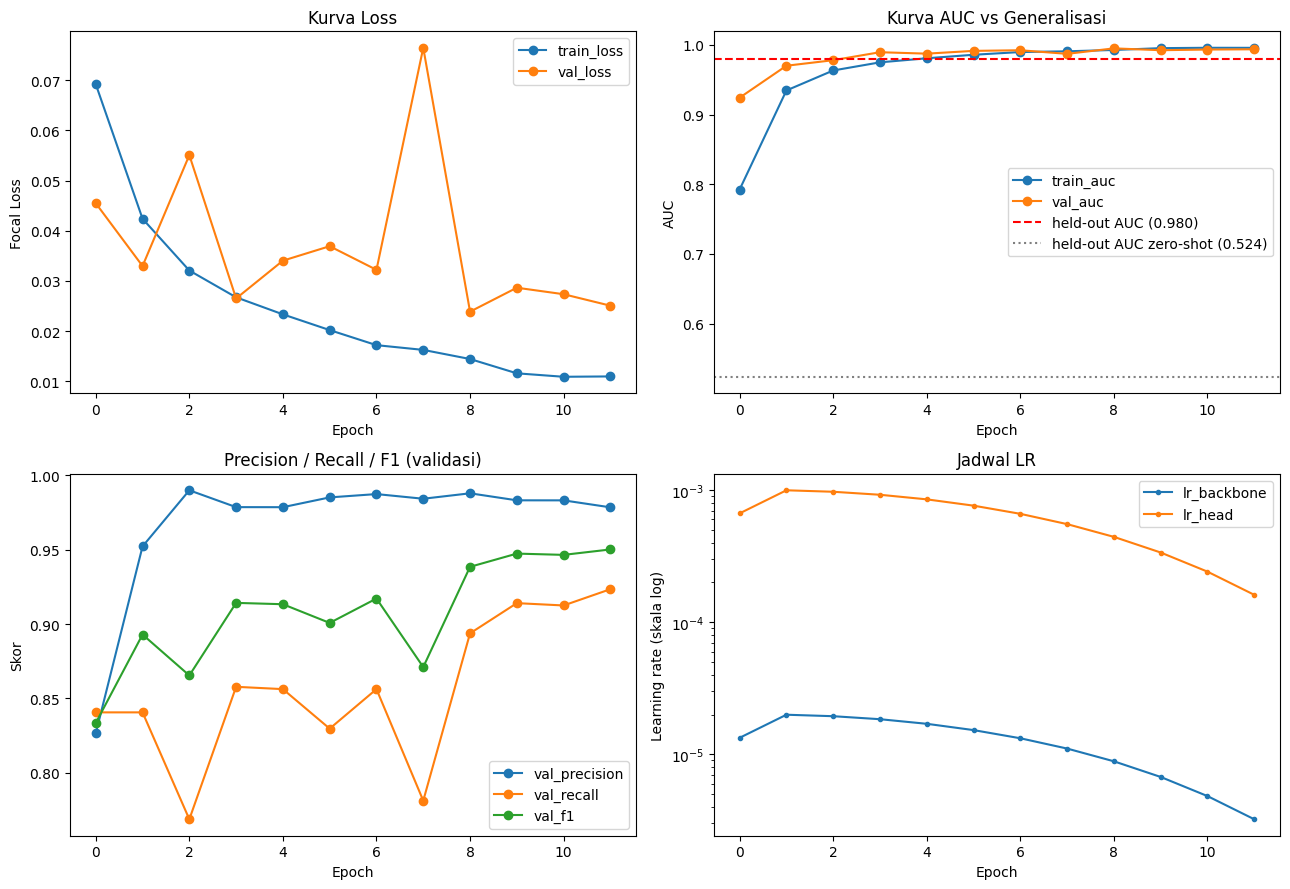

Plot tersimpan: training_curves.png


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.plot(history["train_loss"], marker="o", label="train_loss")
ax.plot(history["val_loss"], marker="o", label="val_loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Focal Loss")
ax.set_title("Kurva Loss")
ax.legend()

ax = axes[0, 1]
ax.plot(history["train_auc"], marker="o", label="train_auc")
ax.plot(history["val_auc"], marker="o", label="val_auc")
ax.axhline(auc_embedding_finetuned, color="red", ls="--", label=f"held-out AUC ({auc_embedding_finetuned:.3f})")
ax.axhline(auc_embedding_original, color="gray", ls=":", label=f"held-out AUC zero-shot ({auc_embedding_original:.3f})")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
ax.set_title("Kurva AUC vs Generalisasi")
ax.legend()

ax = axes[1, 0]
ax.plot(history["val_precision"], marker="o", label="val_precision")
ax.plot(history["val_recall"], marker="o", label="val_recall")
ax.plot(history["val_f1"], marker="o", label="val_f1")
ax.set_xlabel("Epoch"); ax.set_ylabel("Skor")
ax.set_title("Precision / Recall / F1 (validasi)")
ax.legend()

ax = axes[1, 1]
ax.plot(history["lr_backbone"], marker=".", label="lr_backbone")
ax.plot(history["lr_head"], marker=".", label="lr_head")
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate (skala log)")
ax.set_title("Jadwal LR")
ax.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Plot tersimpan: training_curves.png")

# Bagian IV — Walkthrough Referensi: Alur Inferensi Penuh (Blok B–E)

## 19. Blok B — Encoder (Sudah Ada)


## 20. Blok C — Kalibrasi Instance-Specific


In [ ]:
from dataclasses import dataclass as _dc


@_dc
class MachineBaseline:
    machine_label: str
    n_windows: int
    embeddings: np.ndarray
    backend_stats: Dict[str, Dict[str, float]]
    calibration_quality: str


def embed_windows(windows: List[np.ndarray]) -> np.ndarray:
    """Encoder Blok B diterapkan ke banyak window sekaligus."""
    batch = torch.stack([torch.from_numpy(w.astype(np.float32)) for w in windows]).to(device)
    return model.embed(batch).cpu().numpy()


def build_baseline(embeddings: np.ndarray, machine_label: str, cfg: Config) -> MachineBaseline:
    n = embeddings.shape[0]
    quality = "baik" if n >= cfg.min_calibration_windows else "rendah"

    raw_by_backend: Dict[str, list] = {name: [] for name in ("cosine", "mahalanobis", "knn", "pca")}
    for i in range(n):
        bank_loo = np.delete(embeddings, i, axis=0)
        if len(bank_loo) < 2:
            continue
        raw = compute_all_backend_scores(embeddings[i], bank_loo, cfg)
        for name, val in raw.items():
            raw_by_backend[name].append(val)

    backend_stats: Dict[str, Dict[str, float]] = {}
    for name, scores in raw_by_backend.items():
        arr = np.array(scores) if scores else np.array([0.0])
        backend_stats[name] = {"mu": float(arr.mean()), "sigma": float(arr.std() + 1e-8)}

    return MachineBaseline(
        machine_label=machine_label, n_windows=n, embeddings=embeddings.astype(np.float32),
        backend_stats=backend_stats, calibration_quality=quality,
    )


print("Blok C (kalibrasi) siap. Catatan: compute_all_backend_scores didefinisikan di Bagian 21 -- "
      "jalankan Bagian 21 sebelum memanggil build_baseline().")

## 21. Blok D — Multi-Backend Scoring & Fusi


In [26]:
def _cosine_score(query: np.ndarray, bank: np.ndarray) -> float:
    bank_norm = bank / (np.linalg.norm(bank, axis=1, keepdims=True) + 1e-12)
    q_norm = query / (np.linalg.norm(query) + 1e-12)
    sims = bank_norm @ q_norm
    return float(1.0 - sims.max())


def _mahalanobis_score(query: np.ndarray, bank: np.ndarray, shrinkage: float) -> float:
    mu = bank.mean(axis=0)
    cov = np.cov(bank, rowvar=False)
    d = cov.shape[0]
    cov_shrunk = (1 - shrinkage) * cov + shrinkage * (np.trace(cov) / d) * np.eye(d)
    try:
        inv = np.linalg.inv(cov_shrunk)
    except np.linalg.LinAlgError:
        inv = np.linalg.pinv(cov_shrunk)
    diff = query - mu
    return float(np.sqrt(max(diff @ inv @ diff.T, 0.0)))


def _knn_density_score(query: np.ndarray, bank: np.ndarray, k: int) -> float:
    dists = np.linalg.norm(bank - query, axis=1)
    k_eff = max(1, min(k, len(dists)))
    return float(np.sort(dists)[:k_eff].mean())


def _pca_residual_score(query: np.ndarray, bank: np.ndarray, variance_target: float) -> float:
    mu = bank.mean(axis=0)
    centered = bank - mu
    _, s, vt = np.linalg.svd(centered, full_matrices=False)
    total = np.sum(s ** 2)
    if total < 1e-12:
        return 0.0
    var_ratio = (s ** 2) / total
    cum = np.cumsum(var_ratio)
    n_components = min(max(1, int(np.searchsorted(cum, variance_target) + 1)), vt.shape[0])
    components = vt[:n_components]
    q_centered = query - mu
    proj = components.T @ (components @ q_centered)
    return float(np.linalg.norm(q_centered - proj))


def compute_all_backend_scores(query: np.ndarray, bank: np.ndarray, cfg: Config) -> Dict[str, float]:
    if len(bank) < 2:
        raise ValueError(f"Memory bank terlalu kecil ({len(bank)} embedding).")
    return {
        "cosine": _cosine_score(query, bank),
        "mahalanobis": _mahalanobis_score(query, bank, cfg.mahalanobis_shrinkage),
        "knn": _knn_density_score(query, bank, cfg.knn_k),
        "pca": _pca_residual_score(query, bank, cfg.pca_variance_target),
    }


def fuse_scores(raw_scores: Dict[str, float], backend_stats: Dict[str, Dict[str, float]]) -> float:
    """Z-normalisasi tiap backend, lalu MINIMUM (bukan rata-rata) -- konservatif,
    semua backend harus sepakat baru dianggap anomali."""
    z_scores = []
    for name, raw in raw_scores.items():
        stats = backend_stats[name]
        z_scores.append((raw - stats["mu"]) / stats["sigma"])
    return float(min(z_scores))


print("Blok D (scoring) siap.")

Blok D (scoring) siap.


## 22. Blok E — Keputusan & Interpretasi


In [27]:
from scipy import stats as scipy_stats

DISCLAIMER = "Alat bantu triase, bukan diagnosis mengikat -- tetap perlu inspeksi teknisi."


@_dc
class HealthCard:
    status: str
    z_score: float
    calibration_quality: str
    dominant_indicator: Optional[str]
    disclaimer: str


def _dsp_features(w: np.ndarray) -> np.ndarray:
    kurt = float(scipy_stats.kurtosis(w))
    crest = float(np.max(np.abs(w)) / (np.sqrt(np.mean(w ** 2)) + 1e-12))
    spec = np.abs(np.fft.rfft(w))
    freqs = np.fft.rfftfreq(len(w))
    centroid = float(np.sum(freqs * spec) / (np.sum(spec) + 1e-12))
    return np.array([kurt, crest, centroid])


def _dsp_attribution(window: np.ndarray, calibration_windows: List[np.ndarray]) -> str:
    names = ["kurtosis", "crest_factor", "spectral_centroid"]
    test_feat = _dsp_features(window)
    calib_feats = np.array([_dsp_features(w) for w in calibration_windows])
    mu = calib_feats.mean(axis=0)
    sigma = calib_feats.std(axis=0) + 1e-8
    z = np.abs((test_feat - mu) / sigma)
    return names[int(np.argmax(z))]


def decide(
    window: np.ndarray,
    window_embedding: np.ndarray,
    baseline: MachineBaseline,
    cfg: Config,
    calibration_windows: Optional[List[np.ndarray]] = None,
) -> HealthCard:
    if baseline.calibration_quality == "rendah":
        return HealthCard("KALIBRASI_KURANG", float("nan"), baseline.calibration_quality, None, DISCLAIMER)

    raw_scores = compute_all_backend_scores(window_embedding, baseline.embeddings, cfg)
    z = fuse_scores(raw_scores, baseline.backend_stats)

    if z >= cfg.z_critical:
        status = "CRITICAL"
    elif z >= cfg.z_warning:
        status = "WARNING"
    else:
        status = "NORMAL"

    dominant = None
    if status != "NORMAL" and calibration_windows:
        dominant = _dsp_attribution(window, calibration_windows)

    return HealthCard(status, z, baseline.calibration_quality, dominant, DISCLAIMER)


print("Blok E (keputusan) siap.")

Blok E (keputusan) siap.


## 23. 🎬 DEMO — Alur E2E Nyata: Kalibrasi → Inspeksi → Kartu Hasil


In [ ]:
import random as _random
_rng_demo = _random.Random(CFG.seed)

demo_calib_paths = train_df[train_df.label == "normal"]["path"].tolist()[:20]
demo_test_normal = val_df[val_df.label == "normal"]["path"].tolist()
demo_test_abnormal = val_df[val_df.label == "abnormal"]["path"].tolist()

assert len(demo_calib_paths) >= 5, "Tidak cukup klip normal untuk demo kalibrasi."
assert demo_test_normal, "Tidak ada klip normal di val_df untuk demo."
assert demo_test_abnormal, "Tidak ada klip abnormal di val_df untuk demo."

demo_test_normal_path = demo_test_normal[0]
demo_test_abnormal_path = demo_test_abnormal[0]

print("=" * 70)
print("TAHAP 1: KALIBRASI")
print("=" * 70)
print(f"Memakai {len(demo_calib_paths)} klip normal sebagai sesi kalibrasi...")

calib_windows_demo: List[np.ndarray] = []
for p in demo_calib_paths:
    raw = load_audio(p, CFG)
    print(f"  {Path(p).name}: durasi mentah {len(raw)/CFG.sr:.1f}s", end="")
    xc = condition(raw, CFG.sr, CFG)
    windows = make_windows(xc, CFG.sr, CFG)
    print(f" -> {len(windows)} window setelah kondisi+windowing")
    calib_windows_demo.extend(windows)

print(f"\nTotal window kalibrasi: {len(calib_windows_demo)}")
calib_embeddings_demo = embed_windows(calib_windows_demo)
print(f"Embedding: shape {calib_embeddings_demo.shape}")

baseline_demo = build_baseline(calib_embeddings_demo, "Demo Machine", CFG)
print(f"MachineBaseline dibangun: n_windows={baseline_demo.n_windows}, "
      f"kualitas={baseline_demo.calibration_quality}")
print("Statistik backend (mu, sigma) hasil self-score leave-one-out:")
for name, stats in baseline_demo.backend_stats.items():
    print(f"  {name:12s}: mu={stats['mu']:.4f}  sigma={stats['sigma']:.4f}")

In [29]:
def run_inspection_demo(audio_path: str, label_gt: str) -> None:
    print("=" * 70)
    print(f"TAHAP 2: INSPEKSI -- {Path(audio_path).name}  (ground truth: {label_gt})")
    print("=" * 70)
    raw = load_audio(audio_path, CFG)
    print(f"1. Audio dimuat: {len(raw)/CFG.sr:.1f} detik, {CFG.sr}Hz")

    xc = condition(raw, CFG.sr, CFG)
    print(f"2. Setelah condition() [bandpass+notch+normalize"
          f"{'+denoise' if CFG.enable_denoise else ''}]: peak={np.max(np.abs(xc)):.3f}")

    windows = make_windows(xc, CFG.sr, CFG)
    print(f"3. Setelah make_windows(): {len(windows)} window {CFG.window_sec}s (hop {CFG.hop_sec}s)")
    if not windows:
        print("   Tidak ada window valid -- quality gate menolak semua window. Berhenti.")
        return
    window = windows[0]

    embedding = embed_windows([window])[0]
    print(f"4. Setelah encoder.embed(): vektor dim={embedding.shape[0]}, "
          f"norm={np.linalg.norm(embedding):.3f} (harus ~1.0, L2-normalized)")

    raw_scores = compute_all_backend_scores(embedding, baseline_demo.embeddings, CFG)
    print("5. Skor mentah 4 backend terhadap memory bank kalibrasi:")
    for name, val in raw_scores.items():
        print(f"     {name:12s}: {val:.4f}")

    z = fuse_scores(raw_scores, baseline_demo.backend_stats)
    print(f"6. Setelah z-normalisasi + fusi MINIMUM: z = {z:.3f}  "
          f"(ambang WARNING={CFG.z_warning}, CRITICAL={CFG.z_critical})")

    card = decide(window, embedding, baseline_demo, CFG, calibration_windows=calib_windows_demo)
    print(f"\n>>> HASIL AKHIR: status={card.status}  z={card.z_score:.3f}  "
          f"indikator_dominan={card.dominant_indicator}")
    print(f">>> {card.disclaimer}")
    match = "COCOK" if (card.status == "NORMAL") == (label_gt == "normal") else "TIDAK COCOK"
    print(f">>> vs ground truth ({label_gt}): {match}")


run_inspection_demo(demo_test_normal_path, "normal")
print()
run_inspection_demo(demo_test_abnormal_path, "abnormal")

TAHAP 2: INSPEKSI -- 00000354.wav  (ground truth: normal)
1. Audio dimuat: 10.0 detik, 16000Hz
2. Setelah condition() [bandpass+notch+normalize]: peak=1.000
3. Setelah make_windows(): 9 window 2.0s (hop 1.0s)
4. Setelah encoder.embed(): vektor dim=768, norm=1.000 (harus ~1.0, L2-normalized)
5. Skor mentah 4 backend terhadap memory bank kalibrasi:
     cosine      : 0.1588
     mahalanobis : 35.9593
     knn         : 0.5943
     pca         : 0.3356
6. Setelah z-normalisasi + fusi MINIMUM: z = 2.923  (ambang WARNING=3.0, CRITICAL=6.0)

>>> HASIL AKHIR: status=NORMAL  z=2.923  indikator_dominan=None
>>> Alat bantu triase, bukan diagnosis mengikat -- tetap perlu inspeksi teknisi.
>>> vs ground truth (normal): COCOK

TAHAP 2: INSPEKSI -- 00000322.wav  (ground truth: abnormal)
1. Audio dimuat: 10.0 detik, 16000Hz
2. Setelah condition() [bandpass+notch+normalize]: peak=1.000
3. Setelah make_windows(): 9 window 2.0s (hop 1.0s)
4. Setelah encoder.embed(): vektor dim=768, norm=1.000 (harus ~1.

# Bagian V — Ablasi B0 → B1 → B2 vs Baseline Resmi

## 24. Konfigurasi Evaluasi & Anchor Baseline Resmi


In [30]:
N_SEEDS_ABLATION = 3
MAX_TEST_CLIPS_PER_CLASS = 150

OFFICIAL_HITACHI_BASELINE_MINUS6DB = {
    "id_00": 0.5757, "id_02": 0.6401, "id_04": 0.5715,
}
anchor = sum(OFFICIAL_HITACHI_BASELINE_MINUS6DB.values()) / len(OFFICIAL_HITACHI_BASELINE_MINUS6DB)
print(f"Anchor baseline resmi (fan -6dB, rata-rata): {anchor:.4f}")
if DATASET_MODE != "mimii":
    print("PERHATIAN: DATASET_MODE bukan 'mimii' -- perbandingan ke baseline resmi Hitachi "
          "TIDAK APPLICABLE (baseline itu diukur di dataset MIMII, bukan dataset custom Anda). "
          "Bagian ablasi di bawah tetap jalan untuk mengukur delta ANTAR TAHAP di data Anda "
          "sendiri, tapi jangan bandingkan angkanya langsung ke tabel Hitachi.")

Anchor baseline resmi (fan -6dB, rata-rata): 0.5958
PERHATIAN: DATASET_MODE bukan 'mimii' -- perbandingan ke baseline resmi Hitachi TIDAK APPLICABLE (baseline itu diukur di dataset MIMII, bukan dataset custom Anda). Bagian ablasi di bawah tetap jalan untuk mengukur delta ANTAR TAHAP di data Anda sendiri, tapi jangan bandingkan angkanya langsung ke tabel Hitachi.


## 25. Fungsi Evaluasi Inti (Reuse Blok C/D dari Bagian 20–21)


In [31]:
def evaluate_machine(
    machine_id: str, manifest: pd.DataFrame, embed_fn: Callable[[List[np.ndarray]], np.ndarray],
    cfg: Config, n_calib: int, seed: int, max_test_per_class: int, backends: Optional[list] = None,
) -> float:
    rng = np.random.RandomState(seed)
    sub = manifest[manifest.model_id == machine_id]
    normal = sub[sub.label == "normal"]["path"].tolist()
    abnormal = sub[sub.label == "abnormal"]["path"].tolist()
    rng.shuffle(normal)
    rng.shuffle(abnormal)

    calib_paths = normal[:n_calib]
    test_paths = normal[n_calib:n_calib + max_test_per_class] + abnormal[:max_test_per_class]
    test_labels = [0] * len(normal[n_calib:n_calib + max_test_per_class]) + [1] * len(abnormal[:max_test_per_class])

    calib_windows = []
    for p in calib_paths:
        calib_windows.extend(make_windows(condition(load_audio(p, cfg), cfg.sr, cfg), cfg.sr, cfg))
    if len(calib_windows) < cfg.min_calibration_windows:
        raise ValueError(f"[{machine_id}] Cuma {len(calib_windows)} window kalibrasi.")
    baseline = build_baseline(embed_fn(calib_windows), machine_id, cfg)
    if backends is not None:
        stats_subset = {k: baseline.backend_stats[k] for k in backends}

    scores, labels = [], []
    for p, y in zip(test_paths, test_labels):
        windows = make_windows(condition(load_audio(p, cfg), cfg.sr, cfg), cfg.sr, cfg)
        if not windows:
            continue
        emb = embed_fn(windows)
        window_z = []
        for e in emb:
            raw = compute_all_backend_scores(e, baseline.embeddings, cfg)
            if backends is not None:
                raw = {k: v for k, v in raw.items() if k in backends}
                z = fuse_scores(raw, stats_subset)
            else:
                z = fuse_scores(raw, baseline.backend_stats)
            window_z.append(z)
        scores.append(float(np.mean(window_z)))
        labels.append(y)

    if len(set(labels)) < 2:
        return float("nan")
    return roc_auc_score(labels, scores)


def evaluate_stage(
    stage_name: str, manifest: pd.DataFrame, machine_ids: list,
    embed_fn: Callable[[List[np.ndarray]], np.ndarray], cfg: Config, backends: Optional[list] = None,
) -> pd.DataFrame:
    rows = []
    for mid in machine_ids:
        aucs = []
        for seed in range(N_SEEDS_ABLATION):
            auc = evaluate_machine(mid, manifest, embed_fn, cfg, 25, seed, MAX_TEST_CLIPS_PER_CLASS, backends)
            aucs.append(auc)
            print(f"  [{stage_name}] {mid} seed={seed}: AUC={auc:.4f}")
        rows.append({"stage": stage_name, "machine_id": mid,
                      "auc_mean": float(np.nanmean(aucs)), "auc_std": float(np.nanstd(aucs))})
    return pd.DataFrame(rows)


print("Fungsi evaluasi siap.")

Fungsi evaluasi siap.


## 26. B0 — Zero-Shot BEATs + Cosine NN Saja


In [ ]:
def embed_fn_zeroshot(windows: List[np.ndarray]) -> np.ndarray:
    batch = torch.stack([torch.from_numpy(w.astype(np.float32)) for w in windows]).to(device)
    return embed_orig(batch).cpu().numpy()


ALL_MACHINE_IDS = sorted(MF.model_id.unique())
print(f"Evaluasi B0 pada machine IDs: {ALL_MACHINE_IDS}")

results_b0 = evaluate_stage("B0_zeroshot_cosine", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, CFG, backends=["cosine"])
print(results_b0)
b0_mean = results_b0["auc_mean"].mean()
print(f"\nRata-rata AUC B0: {b0_mean:.4f}")

Evaluasi B0 pada machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
  [B0_zeroshot_cosine] id_00 seed=0: AUC=0.6631
  [B0_zeroshot_cosine] id_00 seed=1: AUC=0.6380
  [B0_zeroshot_cosine] id_00 seed=2: AUC=0.6638
  [B0_zeroshot_cosine] id_02 seed=0: AUC=0.7069


## 27. B1 — Zero-Shot BEATs + Multi-Backend Fusion


In [ ]:
results_b1 = evaluate_stage("B1_zeroshot_fusion", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, CFG, backends=None)
print(results_b1)
b1_mean = results_b1["auc_mean"].mean()
print(f"\nRata-rata AUC B1: {b1_mean:.4f}  (delta vs B0: {b1_mean - b0_mean:+.4f})")

  [B1_zeroshot_fusion] id_00 seed=0: AUC=0.7213
  [B1_zeroshot_fusion] id_00 seed=1: AUC=0.6475
  [B1_zeroshot_fusion] id_00 seed=2: AUC=0.6455
                stage machine_id  auc_mean   auc_std
0  B1_zeroshot_fusion      id_00  0.671443  0.035291

Rata-rata AUC B1: 0.6714  (delta vs B0: +0.0005)


## 28. B2 — Backbone Fine-Tuned (Hasil Training Notebook Ini) + Multi-Backend


In [ ]:
def embed_fn_finetuned(windows: List[np.ndarray]) -> np.ndarray:
    return embed_windows(windows)


results_b2 = evaluate_stage("B2_finetuned_fusion", MF, ALL_MACHINE_IDS, embed_fn_finetuned, CFG, backends=None)
print(results_b2)
b2_mean = results_b2["auc_mean"].mean()
print(f"\nRata-rata AUC B2: {b2_mean:.4f}  (delta vs B1: {b2_mean - b1_mean:+.4f})")

if DATASET_MODE == "mimii":
    b2_holdout = results_b2[results_b2.machine_id == CFG.holdout_machine_id]
    b1_holdout = results_b1[results_b1.machine_id == CFG.holdout_machine_id]
    if len(b2_holdout) and len(b1_holdout):
        d = float(b2_holdout.auc_mean.iloc[0] - b1_holdout.auc_mean.iloc[0])
        print(f"AUC B2 di held-out unit ({CFG.holdout_machine_id}): "
              f"{float(b2_holdout.auc_mean.iloc[0]):.4f} (delta vs B1: {d:+.4f})")
        if d <= 0:
            print("CATATAN: fine-tuning TIDAK terbukti membantu di unit held-out -- laporkan apa adanya.")

  [B2_finetuned_fusion] id_00 seed=0: AUC=0.9156
  [B2_finetuned_fusion] id_00 seed=1: AUC=0.8478
  [B2_finetuned_fusion] id_00 seed=2: AUC=0.8124
                 stage machine_id  auc_mean   auc_std
0  B2_finetuned_fusion      id_00  0.858607  0.042805

Rata-rata AUC B2: 0.8586  (delta vs B1: +0.1872)


## 29. (Opsional) Ablasi Denoise HPSS


In [ ]:
denoise_target_id = CFG.holdout_machine_id if DATASET_MODE == "mimii" else ALL_MACHINE_IDS[0]
cfg_denoise_on = replace(CFG, enable_denoise=True)

auc_denoise_off = evaluate_machine(denoise_target_id, MF, embed_fn_finetuned, CFG, 25, 0, MAX_TEST_CLIPS_PER_CLASS)
auc_denoise_on = evaluate_machine(denoise_target_id, MF, embed_fn_finetuned, cfg_denoise_on, 25, 0, MAX_TEST_CLIPS_PER_CLASS)

print(f"AUC denoise OFF: {auc_denoise_off:.4f}")
print(f"AUC denoise ON : {auc_denoise_on:.4f}")
print(f"Delta: {auc_denoise_on - auc_denoise_off:+.4f}")
if auc_denoise_on <= auc_denoise_off:
    print("Denoise TIDAK terbukti membantu -- biarkan enable_denoise=False di ai/config.py.")
else:
    print("Denoise terbukti membantu -- pertimbangkan mengubah default, sebutkan angka ini di proposal.")

AUC denoise OFF: 0.9156
AUC denoise ON : 0.9379
Delta: +0.0223
Denoise terbukti membantu -- pertimbangkan mengubah default, sebutkan angka ini di proposal.


## 30. Ringkasan Hasil


In [ ]:
all_results = pd.concat([results_b0, results_b1, results_b2], ignore_index=True)
pivot = all_results.pivot(index="machine_id", columns="stage", values="auc_mean")

if DATASET_MODE == "mimii":
    baseline_series = pd.Series(OFFICIAL_HITACHI_BASELINE_MINUS6DB, name="baseline_resmi_hitachi")
    pivot = pivot.join(baseline_series, how="left")

print(pivot.round(4))
print(f"\nRata-rata per stage:\n{pivot.mean(numeric_only=True).round(4)}")

all_results.to_csv("ablation_results.csv", index=False)
print("\nHasil mentah tersimpan: ablation_results.csv")

stage       B0_zeroshot_cosine  B1_zeroshot_fusion  B2_finetuned_fusion
machine_id                                                             
id_00                    0.671              0.6714               0.8586

Rata-rata per stage:
stage
B0_zeroshot_cosine     0.6710
B1_zeroshot_fusion     0.6714
B2_finetuned_fusion    0.8586
dtype: float64

Hasil mentah tersimpan: ablation_results.csv


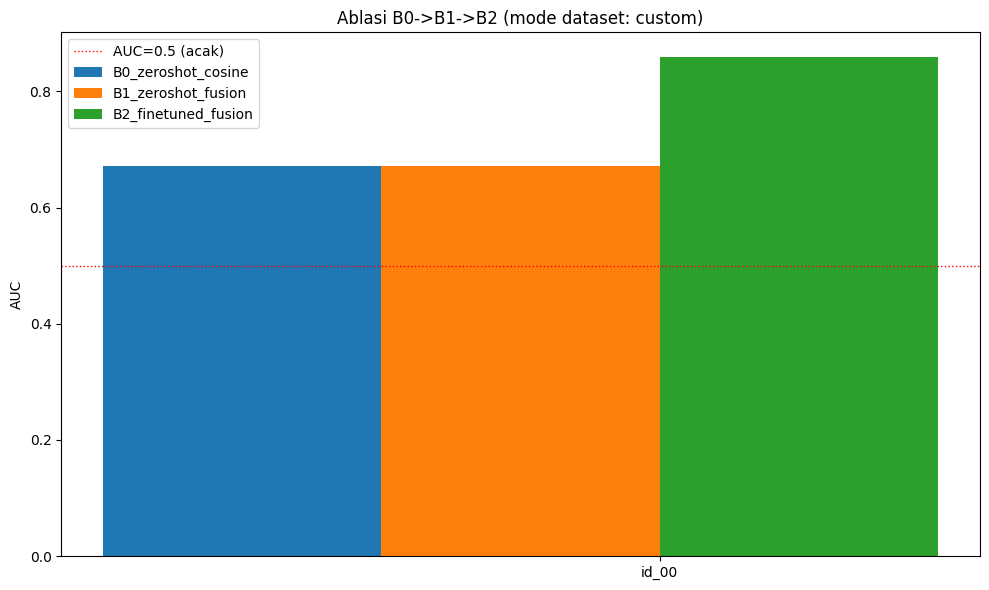

Plot tersimpan: ablation_results.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
stages_present = [s for s in ["B0_zeroshot_cosine", "B1_zeroshot_fusion", "B2_finetuned_fusion"] if s in pivot.columns]
x = np.arange(len(pivot.index))
width = 0.8 / (len(stages_present) + 1)

for i, stage in enumerate(stages_present):
    ax.bar(x + i * width, pivot[stage], width, label=stage)
if "baseline_resmi_hitachi" in pivot.columns:
    ax.bar(x + len(stages_present) * width, pivot["baseline_resmi_hitachi"], width,
           label="Baseline resmi Hitachi (DAE)", color="gray")

ax.set_xticks(x + width * len(stages_present) / 2)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("AUC")
ax.set_title(f"Ablasi B0->B1->B2 (mode dataset: {DATASET_MODE})")
ax.axhline(0.5, color="red", linestyle=":", linewidth=1, label="AUC=0.5 (acak)")
ax.legend()
plt.tight_layout()
plt.savefig("ablation_results.png", dpi=150)
plt.show()
print("Plot tersimpan: ablation_results.png")

In [ ]:
with open("results.md", "w") as f:
    f.write("# Hasil Ablasi B0 -> B1 -> B2 -- AUDIAX\n\n")
    f.write(f"dataset_mode={DATASET_MODE}, N_SEEDS={N_SEEDS_ABLATION}, "
            f"MAX_TEST_CLIPS_PER_CLASS={MAX_TEST_CLIPS_PER_CLASS}\n\n")
    f.write(pivot.round(4).to_markdown())
    f.write("\n\nRata-rata per stage:\n\n")
    f.write(pivot.mean(numeric_only=True).round(4).to_markdown())
    f.write(f"\n\nAblasi denoise ({denoise_target_id}): OFF={auc_denoise_off:.4f}, "
            f"ON={auc_denoise_on:.4f}, delta={auc_denoise_on - auc_denoise_off:+.4f}\n")

print("Tersimpan: results.md")  

Tersimpan: results.md
